# Gas distillation: recovery, energy, and temperature control

**A worked NeqSim study inspired by research opportunity #3697**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/gas_distillation_temperature_control.ipynb) · [Examples catalog](../examples_of_NeqSim_in_Colab.ipynb) · [Research opportunity](https://github.com/equinor/neqsim/issues/3697)

How much NGL can a cold gas feed recover, how much light material remains in the liquid,
and what does tighter temperature control buy us? This notebook connects a native
NeqSim equilibrium-stage column to operating-point selection and an explicitly
assumed dynamic control model. Every table and figure below contains calculated results.

You will build a composable `ProcessSystem`, calculate cryogenic gas separation and a
separate NGL deethanizer, close component and energy balances, select an operating
point under a product-quality constraint, qualify trial tray sensitivities, and
compare fixed-duty operation with PI control of a downstream NGL thermal model.

## 1. What comes from the paper, and what is new here?

Muhammad, Isah, Yusuf, and Nura (2026), *Efficient Temperature Control for Optimizing
Gas Distillation Columns in Nigeria's Gas Processing Industry*, SPE-234910-MS,
[doi:10.2118/234910-MS](https://doi.org/10.2118/234910-MS), motivates temperature
monitoring and feedback around a cryogenic reboiled absorber/demethanizer.
The accessible publisher abstract reports a ten-stage model, an approximate cold
condition of −95 °C, and pressure of 2,275 kPa. It also describes hardware and a PID loop.

**Evidence boundary.** Only the publisher abstract was accessible at authoring
(13 September 2026). Its mass/molar-flow wording is dimensionally inconsistent;
we do not repair or use it as a benchmark. Feed composition, individual tray data,
duties, holdups, tuning, and numerical disturbance trajectories were not available.
This is an independent, synthetic demonstration of relevant calculations, not a
numerical reproduction or experimental validation of the paper. No paper figures
or datasets are redistributed.

| Part | Basis in this notebook | Interpretation |
|---|---|---|
| Thermodynamics and steady column | Current NeqSim source; synthetic C1–C6 mixture | Calculated equilibrium-stage results |
| Cold separator | −95 °C and 22.75 bara chosen from the abstract's scale | Standalone gas-screening calculation |
| Worked column | Eight simple trays, partial condenser and reboiler; synthetic NGL feed | Deethanizer, distinct from the paper |
| Feed rate | 10,000 kg/h, independently assumed | No use of ambiguous paper flow data |
| Dynamic lag, delay, sensor noise | Declared assumptions | Control screening only |
| Controller and disturbance results | Python thermal model with NeqSim liquid properties | Neither Aspen replication nor hardware validation |

The hardware sensor, microcontroller, and actuator chain are outside this model.

## 2. Reproducible setup

Run all cells in order in a fresh Colab runtime. The Python distribution supplies
the JPype bridge; the Java calculations use a **source-built NeqSim JAR** pinned to
the current `master` commit inspected for this study. First setup normally takes
several minutes. The source commit, JAR hash, Java class location, and package
versions are printed and retained.

Local validation can provide `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` for the
same verified source commit and build. Those paths do not bypass provenance checks.

In [1]:
import importlib.metadata as metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys

REQUIRED_PACKAGES = {
    "neqsim": "neqsim==3.18.0",
    "numpy": "numpy>=2.0,<3",
    "pandas": "pandas>=2.2,<4",
    "matplotlib": "matplotlib>=3.9,<4",
}
missing_packages = [
    requirement
    for module, requirement in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    install = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_packages],
        capture_output=True,
        text=True,
    )
    if install.returncode:
        raise RuntimeError(install.stdout + install.stderr)

print("Python:", sys.version.split()[0])
for package in ["neqsim", "JPype1", "numpy", "pandas", "matplotlib"]:
    print(f"{package}: {metadata.version(package)}")

Python: 3.12.14
neqsim: 3.18.0
JPype1: 1.7.1
numpy: 2.5.2
pandas: 3.0.5
matplotlib: 3.11.1


In [2]:
import hashlib
import json

NEQSIM_SOURCE_REF = "1e7fda16e3872f74d918367a708737fbbad93927"
SOURCE_URL = "https://github.com/equinor/neqsim.git"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-study-source"))
source_root = source_root.resolve()


def checked_command(arguments, cwd=None):
    result = subprocess.run(arguments, cwd=cwd, capture_output=True, text=True)
    if result.returncode:
        raise RuntimeError(result.stdout + result.stderr)
    return result.stdout.strip()


if not (source_root / ".git").exists():
    checked_command(["git", "clone", "--filter=blob:none", SOURCE_URL, str(source_root)])
    checked_command(["git", "checkout", "--detach", NEQSIM_SOURCE_REF], cwd=source_root)
resolved_commit = checked_command(["git", "rev-parse", "HEAD"], cwd=source_root)
assert resolved_commit == NEQSIM_SOURCE_REF, "Use the source commit pinned above."
source_changes = checked_command(
    ["git", "status", "--porcelain", "--", "src/main", "pom.xml"],
    cwd=source_root,
)
assert not source_changes, "Source or build inputs have uncommitted changes."

provided_jar = os.environ.get("NEQSIM_SOURCE_JAR")
if provided_jar:
    source_jar = Path(provided_jar).resolve()
else:
    checked_command(
        [
            "bash", "mvnw", "-B", "-q", "-DskipTests", "-Dmaven.test.skip=true",
            "-Dmaven.javadoc.skip=true", "package",
        ],
        cwd=source_root,
    )
    candidates = [
        item for item in (source_root / "target").glob("neqsim-*.jar")
        if not any(marker in item.name for marker in ["sources", "javadoc", "original"])
    ]
    assert len(candidates) == 1, "Expected one source-built runtime JAR."
    source_jar = candidates[0].resolve()
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
import jpype

if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime and run all cells in order.")
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xmx3g", convertStrings=True)
JClass = jpype.JClass
Column = JClass("neqsim.process.equipment.distillation.DistillationColumn")
MeshResidual = JClass("neqsim.process.equipment.distillation.ColumnMeshResidual")
for java_class in [Column, MeshResidual]:
    location = java_class.class_.getProtectionDomain().getCodeSource().getLocation()
    assert Path(str(location.toURI().getPath())).resolve() == source_jar
provenance = {
    "source_commit": resolved_commit,
    "jar_sha256": jar_sha256,
    "class_location": str(location),
    "java_version": str(JClass("java.lang.System").getProperty("java.version")),
    "python_version": sys.version.split()[0],
    "bridge_version": metadata.version("neqsim"),
}
print(json.dumps(provenance, indent=2))

{
  "source_commit": "1e7fda16e3872f74d918367a708737fbbad93927",
  "jar_sha256": "1fd99597cc291c053dc0f21773267f0e823d6d0c735262f879d66b0db2855524",
  "class_location": "file:/workspace/scratch/6bf0d4fd71d2/runtime/neqsim-source/target/neqsim-3.20.0.jar",
  "java_version": "17.0.20",
  "python_version": "3.12.14",
  "bridge_version": "3.18.0"
}


In [3]:
from dataclasses import dataclass
import time

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

Stream = JClass("neqsim.process.equipment.stream.Stream")
Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
Separator = JClass("neqsim.process.equipment.separator.Separator")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")

plt.rcParams.update({
    "figure.dpi": 115,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.titleweight": "bold",
    "figure.constrained_layout.use": True,
})
pd.set_option("display.max_columns", 10)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.precision", 5)
TEAL, ORANGE, NAVY = "#007f86", "#d66b27", "#17324d"
COMPONENTS = [
    "methane", "ethane", "propane", "i-butane", "n-butane",
    "i-pentane", "n-pentane", "n-hexane",
]
MOLE_FRACTIONS = np.array([0.22, 0.34, 0.20, 0.08, 0.08, 0.03, 0.03, 0.02])
assert abs(MOLE_FRACTIONS.sum() - 1.0) < 1e-12


@dataclass(frozen=True)
class Basis:
    feed_kg_h: float = 10000.0
    feed_c: float = 10.0
    top_pressure_bara: float = 24.0
    bottom_pressure_bara: float = 25.0
    top_c: float = 0.0
    bottom_c: float = 80.0
    simple_trays: int = 8
    feed_stage: int = 6


basis = Basis()
display(pd.DataFrame({"Component": COMPONENTS, "Feed mole fraction": MOLE_FRACTIONS}))
display(pd.DataFrame({"Input": list(vars(basis)), "Value": list(vars(basis).values())}))

,Component,Feed mole fraction
0,methane,0.22
1,ethane,0.34
2,propane,0.20
3,i-butane,0.08
4,n-butane,0.08
5,i-pentane,0.03
6,n-pentane,0.03
7,n-hexane,0.02


,Input,Value
0,feed_kg_h,10000.0
1,feed_c,10.0
2,top_pressure_bara,24.0
3,bottom_pressure_bara,25.0
4,top_c,0.0
5,bottom_c,80.0
6,simple_trays,8.0
7,feed_stage,6.0


## 3. Engineering model and boundaries

Use the Soave–Redlich–Kwong EOS with the classic mixing rule for this dry,
sweet hydrocarbon mixture. Water, CO₂, H₂S, hydrates, freezing, entrainment, and
mass-transfer inefficiency are excluded. The deethanizer uses an imposed linear 24–25 bara
pressure profile; pressure drop is not calculated from tray hydraulics.

The rigorous worked example is an NGL deethanizer at 24–25 bara. The synthetic
NGL feed enters internal stage 6 at 10 °C. Index 0 is the partial reboiler, indices
1–8 are simple trays, and index 9 is the partial condenser. Bottom temperature
and condenser temperature are the two independent thermal specifications. Their
duties are outputs. Neither a reflux-ratio target nor a duty target is added.

A separate cryogenic separator screen uses a methane-rich feed and the paper's
cold temperature/pressure scale. These are two independent synthetic cases,
not a coupled plant or a reconstruction of the paper. Initial ten-stage
reboiler-only cryogenic trials failed the bounded convergence check; they are
excluded from product-quality and control claims.

The condenser and feed-cooling duties are heat removal, not electrical power.

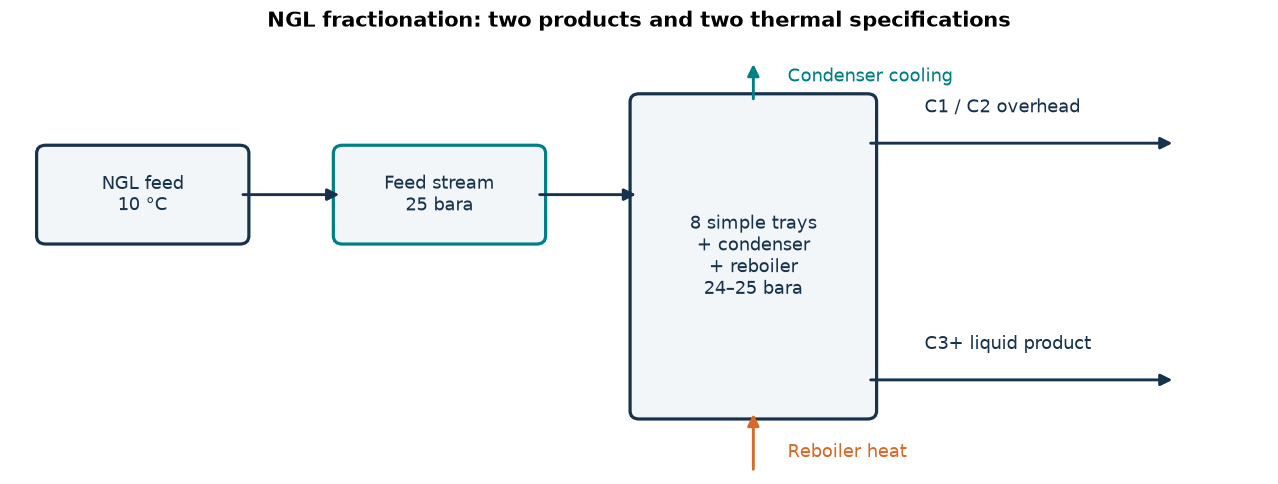

In [4]:
figure, axis = plt.subplots(figsize=(11, 4.1))
axis.set_xlim(0, 11)
axis.set_ylim(0, 4.1)
axis.axis("off")


def box(x, y, width, height, label, color):
    shape = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.08", edgecolor=color, facecolor="#f2f6f8", linewidth=2,
    )
    axis.add_patch(shape)
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", color=NAVY)


def arrow(start, end, color=NAVY):
    axis.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=15,
                                 color=color, linewidth=1.8))


box(0.3, 2.3, 1.7, 0.8, "NGL feed\n10 °C", NAVY)
box(2.9, 2.3, 1.7, 0.8, "Feed stream\n25 bara", TEAL)
box(5.5, 0.6, 2.0, 3.0, "8 simple trays\n+ condenser\n+ reboiler\n24–25 bara", NAVY)
arrow((2.0, 2.7), (2.9, 2.7))
arrow((4.6, 2.7), (5.5, 2.7))
arrow((7.5, 3.2), (10.2, 3.2))
arrow((7.5, 0.9), (10.2, 0.9))
arrow((6.5, 0.0), (6.5, 0.6), ORANGE)
axis.text(8.0, 3.5, "C1 / C2 overhead", color=NAVY)
axis.text(8.0, 1.2, "C3+ liquid product", color=NAVY)
axis.text(6.8, 0.15, "Reboiler heat", color=ORANGE)
axis.text(6.8, 3.8, "Condenser cooling", color=TEAL)
arrow((6.5, 3.6), (6.5, 4.0), TEAL)
axis.set_title("NGL fractionation: two products and two thermal specifications", pad=15)
plt.show()

The figure separates two energy requirements: condenser cooling creates liquid reflux,
while reboiler heat strips light components out of the liquid. Increasing heat can
remove more ethane while also sending valuable propane overhead. We therefore evaluate recovery
and composition together, and report cooling and heating separately.

## 4. First calculation: a cryogenic separator

For this independent screen, take 10,000 kg/h of dry gas with mole fractions
C1/C2/C3/n-C4/n-C5 = 0.80/0.10/0.06/0.025/0.015. Flash it at 22.75 bara over
−105 to −75 °C, then use native `Separator` gas and liquid streams. This directly
connects temperature to phase split and NGL recovery without claiming that one
flash stage substitutes for the paper's column.

Component recovery is based on molar rates. For component $i$:

$$R_{i,L}=\frac{\dot n_{i,L}}{\dot n_{i,F}}$$

Here $R_{i,L}$ is dimensionless; $\dot n_{i,L}$ and $\dot n_{i,F}$ are liquid-product
and feed molar rates in mol/s. A large liquid flow alone does not establish product
quality: it may include considerable dissolved methane.

,Cold feed (°C),Liquid (kg/h),C2 recovery (%),C3 recovery (%),Liquid C1 (mol%),Cooling (kW)
0,-105.0,10000.000,100.000,100.000,80.000,1869.915
3,-97.5,9827.488,99.835,99.980,79.559,1782.902
6,-90.0,5984.050,91.577,98.939,60.420,1361.230
9,-82.5,4899.592,82.724,97.500,48.190,1200.930
12,-75.0,4287.903,72.531,95.233,39.688,1087.415


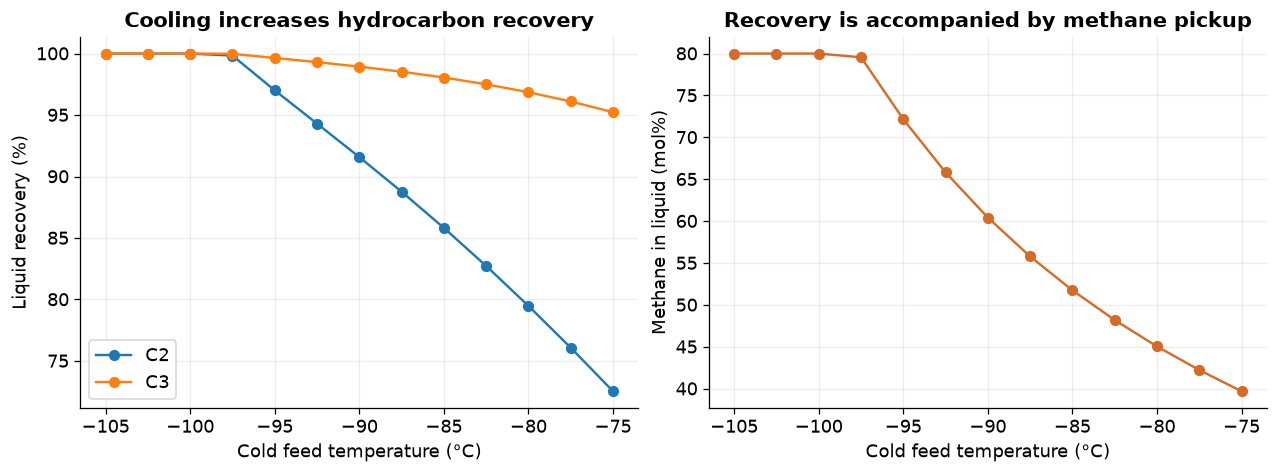

In [5]:
def make_fluid(names, fractions, temperature_c, pressure_bara):
    fluid = JClass("neqsim.thermo.system.SystemSrkEos")(
        temperature_c + 273.15, pressure_bara,
    )
    for name, fraction in zip(names, fractions):
        fluid.addComponent(name, float(fraction))
    fluid.setMixingRule("classic")
    return fluid


def component_rates(stream, names=COMPONENTS):
    molar_rate = float(stream.getFlowRate("mole/sec"))
    return molar_rate * np.array([
        float(stream.getFluid().getComponent(name).getz()) for name in names
    ])


def enthalpy_rate(stream):
    if abs(float(stream.getFlowRate("kg/hr"))) < 1e-12:
        return 0.0
    stream.getFluid().init(3)
    return float(stream.getFluid().getEnthalpy())


cold_names = ["methane", "ethane", "propane", "n-butane", "n-pentane"]
cold_fractions = [0.80, 0.10, 0.06, 0.025, 0.015]
cold_records = []
for cold_c in np.linspace(-105.0, -75.0, 13):
    cold_fluid = make_fluid(cold_names, cold_fractions, 30.0, 22.75)
    warm = Stream("warm gas", cold_fluid)
    warm.setFlowRate(10000.0, "kg/hr")
    cooler = Cooler("cold feed preparation", warm)
    cooler.setOutTemperature(float(cold_c), "C")
    separator = Separator("cold separator", cooler.getOutletStream())
    cold_process = ProcessSystem()
    for equipment in [warm, cooler, separator]:
        cold_process.add(equipment)
    cold_process.run()
    cold_liquid = separator.getLiquidOutStream()
    cold_gas = separator.getGasOutStream()
    incoming = component_rates(warm, cold_names)
    liquid_rates = component_rates(cold_liquid, cold_names)
    gas_rates = component_rates(cold_gas, cold_names)
    cold_records.append({
        "Cold feed (°C)": cold_c,
        "Liquid (kg/h)": float(cold_liquid.getFlowRate("kg/hr")),
        "C2 recovery (%)": 100 * liquid_rates[1] / incoming[1],
        "C3 recovery (%)": 100 * liquid_rates[2] / incoming[2],
        "Liquid C1 (mol%)": 100 * liquid_rates[0] / liquid_rates.sum(),
        "Cooling (kW)": -float(cooler.getDuty()) / 1000,
        "Component error (mol/s)": float(np.max(np.abs(incoming - liquid_rates - gas_rates))),
        "Energy error (W)": (
            enthalpy_rate(cold_liquid) + enthalpy_rate(cold_gas)
            - enthalpy_rate(warm) - float(cooler.getDuty())
        ),
    })
cold_table = pd.DataFrame(cold_records)
display(cold_table.iloc[::3, :6].round(3))
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for component in ["C2", "C3"]:
    axes[0].plot(cold_table["Cold feed (°C)"], cold_table[f"{component} recovery (%)"],
                 marker="o", label=component)
axes[0].set(xlabel="Cold feed temperature (°C)", ylabel="Liquid recovery (%)",
            title="Cooling increases hydrocarbon recovery")
axes[0].legend()
axes[1].plot(cold_table["Cold feed (°C)"], cold_table["Liquid C1 (mol%)"],
             marker="o", color=ORANGE)
axes[1].set(xlabel="Cold feed temperature (°C)", ylabel="Methane in liquid (mol%)",
            title="Recovery is accompanied by methane pickup")
plt.show()

In [6]:
cold_reference = cold_table.loc[np.isclose(cold_table["Cold feed (°C)"], -95.0)].iloc[0]
display(Markdown(
    f"At **−95 °C**, the separator produces **{cold_reference['Liquid (kg/h)']:.0f} kg/h** "
    f"of liquid, with **{cold_reference['C2 recovery (%)']:.1f}% ethane recovery** and "
    f"**{cold_reference['Liquid C1 (mol%)']:.1f} mol% methane** in that liquid. "
    "Colder operation changes both recovery and quality. A fractionation or stripping "
    "step is needed when light-component content matters. This screen should be extended "
    "with impurity/freezing data before representing a real cryogenic feed."
))

At **−95 °C**, the separator produces **7738 kg/h** of liquid, with **97.0% ethane recovery** and **72.2 mol% methane** in that liquid. Colder operation changes both recovery and quality. A fractionation or stripping step is needed when light-component content matters. This screen should be extended with impurity/freezing data before representing a real cryogenic feed.

## 5. A native NGL deethanizer with an independent energy audit

The detailed column uses the synthetic eight-component NGL feed in Section 2.
The harness executes the feed and column in order and checks acceptance immediately;
it retains both in a `ProcessSystem` for reuse without asking that container to
retry an unqualified column repeatedly.
It is a different process case from the methane-rich cold separator above.
`ProcessSystem`, feed `Stream`, the column, and its product streams remain
available for extension.

**Known upstream issue discovered here:** [NeqSim #3698](https://github.com/equinor/neqsim/issues/3698).
On the pinned source, the simultaneous solver can expose stale terminal-duty
getters and stale tray inlet references even when its accepted neighboring outlet
states close MESH balances. We retain both reported and independently calculated
duties below. All energy, optimization, and gain calculations use the latter.
This does not repair the Java energy ports; do not connect those ports to other
equipment without resolving the issue.

For each stage, reconstruct inputs from the adjacent *accepted outlet streams*,
plus any external feed. Stage indices increase upward:

$$\dot n_{i,V,j-1}+\dot n_{i,L,j+1}+\dot n_{i,F,j}=\dot n_{i,V,j}+\dot n_{i,L,j}$$

$$Q_j=H_{V,j}+H_{L,j}-H_{V,j-1}-H_{L,j+1}-H_{F,j}$$

Here $j$ denotes stage index, $V$ and $L$ denote vapor and liquid, and missing
boundary streams contribute zero. Every $H$ is an **enthalpy rate in W**, and
$Q_j$ is heat into that stage in W. Interior adiabatic stages must have $Q_j$
near zero; the two terminal values determine reboiler and condenser duties.
We check every component on every stage, overall mass, interior energy,
equilibrium residual, phase fractions, and agreement with the public products.
A native success flag alone is insufficient.

In [7]:
def stage_audit(column, feed, feed_stage):
    count = int(column.getNumberOfTrays())
    gas = [column.getTray(index).getGasOutStream() for index in range(count)]
    liquid = [column.getTray(index).getLiquidOutStream() for index in range(count)]
    gas_rates = np.array([component_rates(item) for item in gas])
    liquid_rates = np.array([component_rates(item) for item in liquid])
    gas_h = np.array([enthalpy_rate(item) for item in gas])
    liquid_h = np.array([enthalpy_rate(item) for item in liquid])
    feed_rates = component_rates(feed)
    feed_h = enthalpy_rate(feed)
    material_errors = []
    stage_heat = []
    stage_records = []
    for index in range(count):
        incoming = np.zeros(len(COMPONENTS))
        inlet_h = 0.0
        if index > 0:
            incoming += gas_rates[index - 1]
            inlet_h += gas_h[index - 1]
        if index < count - 1:
            incoming += liquid_rates[index + 1]
            inlet_h += liquid_h[index + 1]
        if index == feed_stage:
            incoming += feed_rates
            inlet_h += feed_h
        material_error = gas_rates[index] + liquid_rates[index] - incoming
        material_errors.append(material_error)
        heat = gas_h[index] + liquid_h[index] - inlet_h
        stage_heat.append(heat)
        stage_records.append({
            "Stage": index,
            "Temperature (°C)": float(column.getTray(index).getTemperature()) - 273.15,
            "Pressure (bara)": float(column.getTray(index).getPressure()),
            "Vapor (kg/h)": float(gas[index].getFlowRate("kg/hr")),
            "Liquid (kg/h)": float(liquid[index].getFlowRate("kg/hr")),
            "Net heat (kW)": heat / 1000,
        })
    top = column.getGasOutStream()
    bottom = column.getLiquidOutStream()
    top_rates = component_rates(top)
    bottom_rates = component_rates(bottom)
    heat_scale = max(abs(stage_heat[0]), abs(stage_heat[-1]), 1000.0)
    public_h = enthalpy_rate(top) + enthalpy_rate(bottom) - feed_h
    return {
        "stages": pd.DataFrame(stage_records),
        "component_error": float(np.max(np.abs(material_errors))),
        "external_component_error": float(np.max(np.abs(top_rates + bottom_rates - feed_rates))),
        "product_match_error": float(max(
            np.max(np.abs(top_rates - gas_rates[-1])),
            np.max(np.abs(bottom_rates - liquid_rates[0])),
        )),
        "mass_relative_error": abs(
            float(top.getFlowRate("kg/hr")) + float(bottom.getFlowRate("kg/hr"))
            - float(feed.getFlowRate("kg/hr"))
        ) / float(feed.getFlowRate("kg/hr")),
        "interior_energy_relative_error": float(np.max(np.abs(stage_heat[1:-1]))) / heat_scale,
        "external_energy_relative_error": (
            abs(public_h - stage_heat[0] - stage_heat[-1]) / heat_scale
        ),
        "reboiler_kw": stage_heat[0] / 1000,
        "condenser_kw": stage_heat[-1] / 1000,
        "native_reboiler_kw": float(column.getReboiler().getDuty()) / 1000,
        "native_condenser_kw": float(column.getCondenser().getDuty()) / 1000,
        "native_energy_mismatch_kw": (
            public_h - float(column.getReboiler().getDuty())
            - float(column.getCondenser().getDuty())
        ) / 1000,
        "feed_rates": feed_rates,
        "top_rates": top_rates,
        "bottom_rates": bottom_rates,
    }


def calculate_column(
    bottom_c=80.0, feed_c=10.0, pressure_shift=0.0, top_c=0.0, reference_case=None,
):
    if reference_case is None:
        fluid = make_fluid(COMPONENTS, MOLE_FRACTIONS, feed_c, 25.0 + pressure_shift)
        feed = Stream("synthetic NGL feed", fluid)
        column = Column("NGL deethanizer", basis.simple_trays, True, True)
        column.addFeedStream(feed, basis.feed_stage)
    else:
        column = jpype.JObject(reference_case["column"].copy(), Column)
        feed = column.getInletStreams().get(0)
        feed.setTemperature(feed_c, "C")
        feed.setPressure(25.0 + pressure_shift, "bara")
    feed.setFlowRate(basis.feed_kg_h, "kg/hr")
    column.setCondenserTemperature(top_c, "C")
    column.setReboilerTemperature(bottom_c, "C")
    column.setTopPressure(24.0 + pressure_shift)
    column.setBottomPressure(25.0 + pressure_shift)
    column.setSolverType(Column.SolverType.NAPHTALI_SANDHOLM)
    column.setMaxNumberOfIterations(80, True)
    column.setTemperatureTolerance(1e-5)
    process = ProcessSystem()
    process.add(feed)
    process.add(column)
    started = time.perf_counter()
    feed.run()
    print(f"Solving column: bottom {bottom_c:.2f} °C, feed {feed_c:.2f} °C")
    column.run()
    audit = stage_audit(column, feed, basis.feed_stage)
    equilibrium_error = float(column.getLastMeshEquilibriumResidualNorm())
    acceptance = {
        "native solve accepted": bool(column.solved()),
        "no feed-flash fallback": not bool(column.wasFeedFlashFallbackApplied()),
        "stage components": audit["component_error"] < 1e-5,
        "external components": audit["external_component_error"] < 1e-5,
        "public products match accepted terminal streams": audit["product_match_error"] < 1e-5,
        "external mass": audit["mass_relative_error"] < 1e-6,
        "interior stage energies": audit["interior_energy_relative_error"] < 1e-5,
        "external audited energy": audit["external_energy_relative_error"] < 1e-5,
        "equilibrium": np.isfinite(equilibrium_error) and equilibrium_error < 1e-6,
        "positive heating and cooling": audit["reboiler_kw"] > 0 and audit["condenser_kw"] < 0,
        "finite nonnegative product rates": (
            np.isfinite(audit["bottom_rates"]).all()
            and np.isfinite(audit["top_rates"]).all()
            and np.min(audit["bottom_rates"]) >= 0
            and np.min(audit["top_rates"]) >= 0
        ),
    }
    failed = [name for name, passed in acceptance.items() if not passed]
    if failed:
        raise RuntimeError(f"Rejected column: {failed}\n{column.getConvergenceDiagnostics()}")
    audit.update({
        "process": process, "feed": feed, "column": column,
        "checks": acceptance, "seconds": time.perf_counter() - started,
        "bottom_c": bottom_c, "feed_c": feed_c, "pressure_shift": pressure_shift,
    })
    print(f"Accepted in {audit['seconds']:.2f} s; audited duty {audit['reboiler_kw']:.3f} kW")
    return audit


def case_row(case):
    bottom = case["bottom_rates"]
    feed = case["feed_rates"]
    return {
        "Bottom (°C)": case["bottom_c"],
        "Reboiler (kW)": case["reboiler_kw"],
        "Condenser cooling (kW)": -case["condenser_kw"],
        "C2 in bottoms (mol%)": 100 * bottom[1] / bottom.sum(),
        "C3 recovery (%)": 100 * bottom[2] / feed[2],
        "Liquid (kg/h)": float(case["column"].getLiquidOutStream().getFlowRate("kg/hr")),
    }


baseline = calculate_column()
display(pd.DataFrame([case_row(baseline)]).round(4))
print("Native status:", baseline["column"].getLastSolveStatus())
print("Native solver:", baseline["column"].getLastSolverTypeUsed())
print("Iterations:", baseline["column"].getLastIterationCount())
print(f"Runtime: {baseline['seconds']:.2f} s")

Solving column: bottom 80.00 °C, feed 10.00 °C
Accepted in 3.02 s; audited duty 552.257 kW
Native status: RECONCILED_PRODUCTS
Native solver: NAPHTALI_SANDHOLM
Iterations: 7
Runtime: 3.02 s


,Bottom (°C),Reboiler (kW),Condenser cooling (kW),C2 in bottoms (mol%),C3 recovery (%),Liquid (kg/h)
0,80.0,552.2565,103.2267,15.2465,74.478,6189.2056


Optimization uses the accepted-stream audit; native duty getters are excluded (#3698).


,Quantity,Native getters (kW),Accepted-stream audit (kW)
0,Reboiler,30.56650,552.25654
1,Condenser,-70.86577,-103.22668
2,External energy mismatch,489.32912,0.00000


,Stage,Temperature (°C),Pressure (bara),Vapor (kg/h),Liquid (kg/h),Net heat (kW)
0,0,80.0000,25.0000,5593.3450,6189.2056,552.2565
1,1,60.5676,24.8889,5042.1223,11782.5507,0.0000
2,2,49.3347,24.7778,4653.5821,11231.3280,-0.0000
3,3,42.4099,24.6667,4303.3856,10842.7877,-0.0000
4,4,37.1744,24.5556,3773.1578,10492.5912,-0.0000
5,5,30.5162,24.4444,2819.2575,9962.3635,-0.0000
6,6,17.6067,24.3333,4561.2486,9008.4631,-0.0000
7,7,14.4445,24.2222,4634.9411,750.4543,-0.0000
8,8,10.7208,24.1111,4668.4176,824.1467,0.0000
9,9,0.0000,24.0000,3810.7944,857.6233,-103.2267


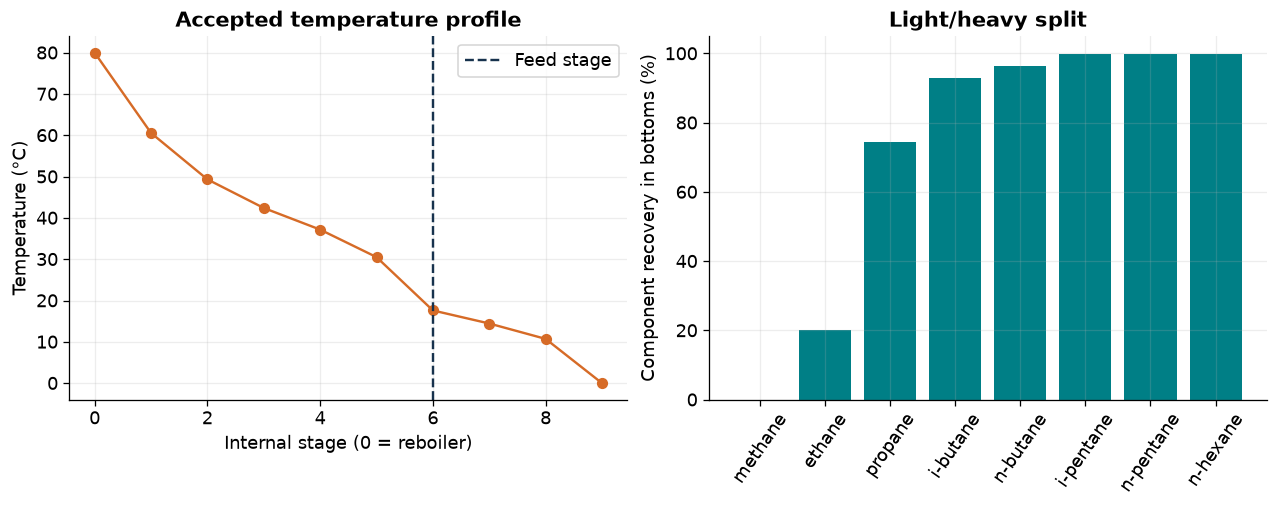

In [8]:
duty_table = pd.DataFrame({
    "Quantity": ["Reboiler", "Condenser", "External energy mismatch"],
    "Native getters (kW)": [
        baseline["native_reboiler_kw"], baseline["native_condenser_kw"],
        baseline["native_energy_mismatch_kw"],
    ],
    "Accepted-stream audit (kW)": [
        baseline["reboiler_kw"], baseline["condenser_kw"],
        baseline["external_energy_relative_error"] * abs(baseline["reboiler_kw"]),
    ],
})
display(duty_table.round(6))
print("Optimization uses the accepted-stream audit; native duty getters are excluded (#3698).")
display(baseline["stages"].round(4))
figure, axes = plt.subplots(1, 2, figsize=(11, 4.3))
stage_table = baseline["stages"]
axes[0].plot(stage_table["Stage"], stage_table["Temperature (°C)"], "o-", color=ORANGE)
axes[0].axvline(basis.feed_stage, color=NAVY, linestyle="--", label="Feed stage")
axes[0].set(xlabel="Internal stage (0 = reboiler)", ylabel="Temperature (°C)",
            title="Accepted temperature profile")
axes[0].legend()
recovery = 100 * baseline["bottom_rates"] / baseline["feed_rates"]
axes[1].bar(COMPONENTS, recovery, color=TEAL)
axes[1].tick_params(axis="x", labelrotation=55)
axes[1].set(ylabel="Component recovery in bottoms (%)", ylim=(0, 105),
            title="Light/heavy split")
plt.show()

In [9]:
display(Markdown(
    f"The accepted NGL case needs **{baseline['reboiler_kw']:.1f} kW of reboiler heat** "
    f"and **{-baseline['condenser_kw']:.1f} kW of condenser cooling**. "
    f"Propane recovery in the liquid is **{recovery[2]:.1f}%**; the bottoms still contain "
    f"**{case_row(baseline)['C2 in bottoms (mol%)']:.1f} mol% ethane**. "
    "The temperature gradient supports light-component stripping. Its shape alone does "
    "not prove convergence: the neighboring-stream material and energy checks qualify it. "
    "Use the independently audited duties for this pinned version and follow #3698 before "
    "using native column energy ports for heat integration."
))

The accepted NGL case needs **552.3 kW of reboiler heat** and **103.2 kW of condenser cooling**. Propane recovery in the liquid is **74.5%**; the bottoms still contain **15.2 mol% ethane**. The temperature gradient supports light-component stripping. Its shape alone does not prove convergence: the neighboring-stream material and energy checks qualify it. Use the independently audited duties for this pinned version and follow #3698 before using native column energy ports for heat integration.

## 6. Operating-point selection: quality versus energy and recovery

Sweep the reboiler temperature while holding feed, top temperature, and pressure
profile fixed. Every point starts from an independent copy of the accepted base
column state and is independently audited. This avoids carrying one sweep point
into the next; it does not guarantee convergence from arbitrary cold starts.
The illustrative teaching constraints are **bottoms ethane ≤12 mol%** and
**propane recovery ≥65%**. These are chosen exercise constraints, not commercial
product specifications or paper values.

$$\min_{T_B\in\mathcal G} Q_R(T_B)\quad\text{subject to}\quad x_{C2,B}\leq0.12,\;R_{C3,B}\geq0.65$$

$T_B$ is bottom temperature in °C; $\mathcal G$ is the displayed discrete grid;
$Q_R$ is audited reboiler duty in kW; $x_{C2,B}$ is bottoms ethane mole fraction.
This is a finite candidate search over the listed, qualified operating points, not a
claim of a global continuous optimum or uniqueness of the column solution.
Pre-validation at 85 °C failed acceptance, and a cold start at 90 °C reached
a different accepted solution branch. Those points are excluded pending further
solver/branch qualification; their absence is not evidence of physical infeasibility.
Condenser cooling is reported separately; a utility-system model would be needed
to optimize electrical power or operating cost.

Solving column: bottom 70.00 °C, feed 10.00 °C
Accepted in 1.90 s; audited duty 463.573 kW
Solving column: bottom 75.00 °C, feed 10.00 °C
Accepted in 2.37 s; audited duty 508.866 kW
Solving column: bottom 80.00 °C, feed 10.00 °C
Accepted in 4.27 s; audited duty 552.257 kW
Solving column: bottom 82.50 °C, feed 10.00 °C
Accepted in 1.44 s; audited duty 573.609 kW
Solving column: bottom 87.50 °C, feed 10.00 °C
Accepted in 0.50 s; audited duty 616.708 kW
Solving column: bottom 92.50 °C, feed 10.00 °C
Accepted in 2.17 s; audited duty 663.002 kW
Solving column: bottom 95.00 °C, feed 10.00 °C
Accepted in 2.76 s; audited duty 689.361 kW


,Bottom (°C),Reboiler (kW),Condenser cooling (kW),C2 in bottoms (mol%),C3 recovery (%),Liquid (kg/h),Feasible
0,70.0,463.573,74.899,21.593,76.759,6526.760,False
1,75.0,508.866,89.174,18.368,75.564,6347.670,False
2,80.0,552.257,103.227,15.247,74.478,6189.206,False
3,82.5,573.609,110.427,13.724,73.949,6116.219,False
4,87.5,616.708,126.084,10.756,72.848,5980.050,True
5,92.5,663.002,145.904,7.895,71.542,5853.385,True
6,95.0,689.361,159.339,6.515,70.720,5792.079,True


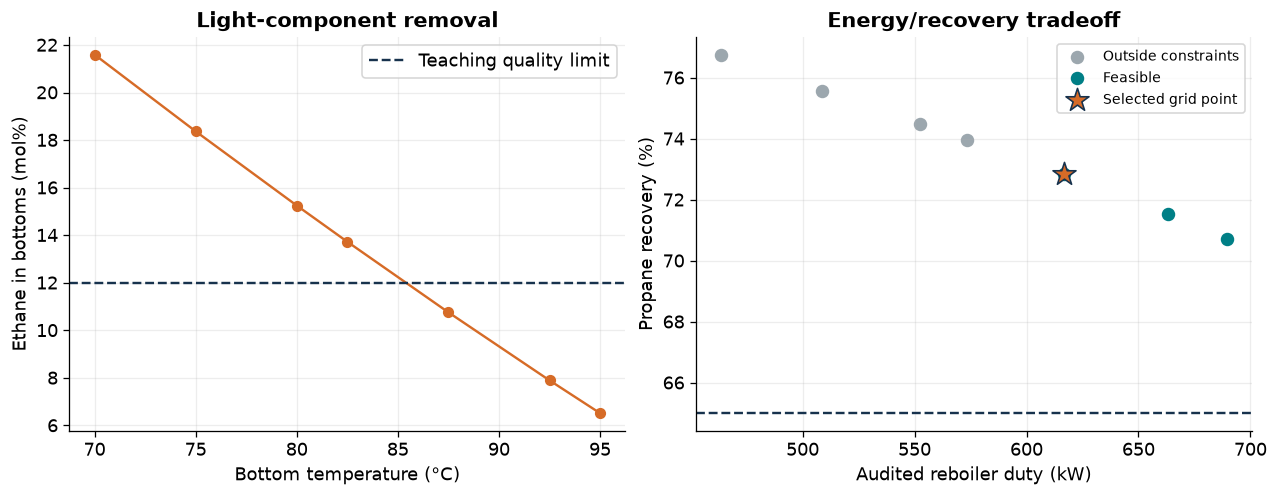

In [10]:
scan_cases = []
scan_rejections = []
for value in [70.0, 75.0, 80.0, 82.5, 87.5, 92.5, 95.0]:
    try:
        scan_cases.append(calculate_column(bottom_c=float(value), reference_case=baseline))
    except RuntimeError as error:
        scan_rejections.append({"Bottom (°C)": value, "Reason": str(error)})
if scan_rejections:
    print("Rejected candidate diagnostics (excluded from every result and optimization):")
    for rejection in scan_rejections:
        print(rejection["Bottom (°C)"], rejection["Reason"])
assert scan_cases, "No independently accepted operating points."
scan_table = pd.DataFrame([case_row(case) for case in scan_cases])
scan_table["Feasible"] = (
    (scan_table["C2 in bottoms (mol%)"] <= 12.0)
    & (scan_table["C3 recovery (%)"] >= 65.0)
)
display(scan_table.round(3))
feasible_indices = scan_table.index[scan_table["Feasible"]]
assert len(feasible_indices) > 0, "No candidate meets both teaching constraints."
selected_index = int(scan_table.loc[feasible_indices, "Reboiler (kW)"].idxmin())
selected = scan_cases[selected_index]
selected_row = scan_table.loc[selected_index]
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(scan_table["Bottom (°C)"], scan_table["C2 in bottoms (mol%)"], "o-", color=ORANGE)
axes[0].axhline(12, color=NAVY, linestyle="--", label="Teaching quality limit")
axes[0].set(xlabel="Bottom temperature (°C)", ylabel="Ethane in bottoms (mol%)",
            title="Light-component removal")
axes[0].legend()
for feasible, group in scan_table.groupby("Feasible"):
    axes[1].scatter(group["Reboiler (kW)"], group["C3 recovery (%)"], s=55,
                    color=TEAL if feasible else "#9ca7ae",
                    label="Feasible" if feasible else "Outside constraints")
axes[1].scatter(selected_row["Reboiler (kW)"], selected_row["C3 recovery (%)"],
                marker="*", s=230, color=ORANGE, edgecolor=NAVY, label="Selected grid point")
axes[1].axhline(65, color=NAVY, linestyle="--")
axes[1].set(xlabel="Audited reboiler duty (kW)", ylabel="Propane recovery (%)",
            title="Energy/recovery tradeoff")
axes[1].legend(fontsize=9)
plt.show()

In [11]:
display(Markdown(
    f"The lowest-duty accepted feasible grid point is **{selected_row['Bottom (°C)']:.1f} °C**: "
    f"**{selected_row['Reboiler (kW)']:.1f} kW** of reboiler heat, "
    f"**{selected_row['C2 in bottoms (mol%)']:.2f} mol% ethane** in the liquid, and "
    f"**{selected_row['C3 recovery (%)']:.2f}% propane recovery**. "
    "Higher temperature removes more light material but can sacrifice saleable propane. "
    "Choose the lowest energy candidate that meets both constraints, then refine its "
    "neighborhood and test the real product specification. "
    "The displayed grid is deliberately sparse and nonuniform."
))

The lowest-duty accepted feasible grid point is **87.5 °C**: **616.7 kW** of reboiler heat, **10.76 mol% ethane** in the liquid, and **72.85% propane recovery**. Higher temperature removes more light material but can sacrifice saleable propane. Choose the lowest energy candidate that meets both constraints, then refine its neighborhood and test the real product specification. The displayed grid is deliberately sparse and nonuniform.

## 7. Which tray temperature carries useful control information?

Calculate centered trial finite differences at the selected operating point. Perturb
bottom temperature by ±0.5 °C, feed temperature by ±1 °C, and the full pressure
profile by ±0.25 bar. The heat-to-temperature gain for internal tray $j$ is

$$K_{Q,j}=\frac{\partial T_j/\partial T_B}{\partial Q_R/\partial T_B}$$

Its units are K/kW. For disturbance $d$ (feed temperature or pressure), transform
the fixed-bottom-temperature perturbation to **fixed duty** with the chain rule:

$$K_{d,j}=\left(\frac{\partial T_j}{\partial d}\right)_{T_B}-K_{Q,j}\left(\frac{\partial Q_R}{\partial d}\right)_{T_B}$$

The resulting feed-temperature gain is K/K and pressure gain is K/bar. Selecting
an internal tray avoids merely observing an imposed endpoint specification.
We rank trays by local duty sensitivity; hydraulic response, analyzer accuracy,
sensor placement, and plant disturbance tests are still needed for control design.

Solving column: bottom 87.00 °C, feed 10.00 °C
Accepted in 1.12 s; audited duty 612.323 kW
Solving column: bottom 88.00 °C, feed 10.00 °C
Accepted in 2.63 s; audited duty 562.991 kW
Solving column: bottom 87.50 °C, feed 9.00 °C
Accepted in 3.26 s; audited duty 575.922 kW
Solving column: bottom 87.50 °C, feed 11.00 °C
Accepted in 2.68 s; audited duty 608.549 kW
Solving column: bottom 87.50 °C, feed 10.00 °C
Accepted in 2.54 s; audited duty 565.788 kW
Solving column: bottom 87.50 °C, feed 10.00 °C
Accepted in 3.21 s; audited duty 568.312 kW


,Stage,Duty gain (K/kW),Feed gain (K/K),Pressure gain (K/bar)
0,1,-0.01222,0.50976,-0.26181
1,2,-0.00814,0.58261,-0.21170
2,3,-0.00587,0.57986,0.07295
3,4,-0.00386,0.54948,0.31813
4,5,0.00003,0.55380,0.35042
5,6,0.00852,0.68778,0.32763
6,7,-0.05024,0.33041,0.87494
7,8,-0.05819,0.79457,1.47530


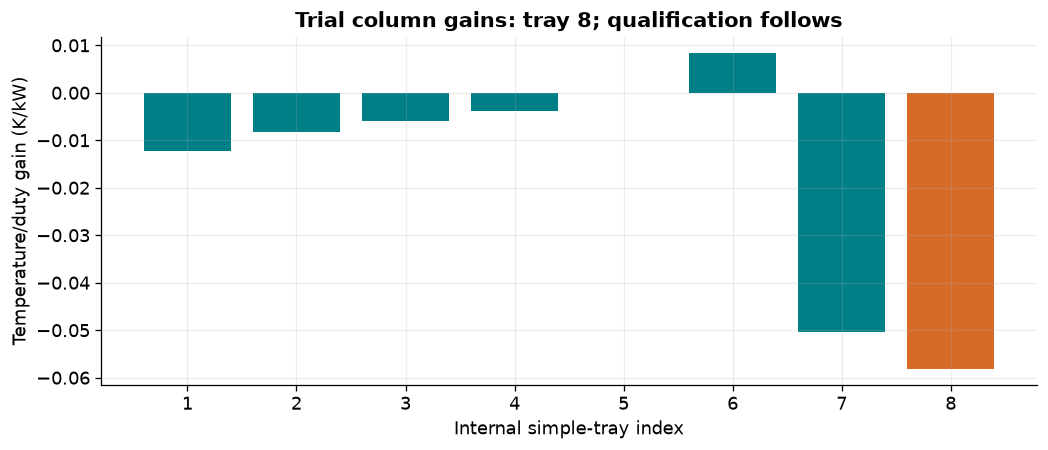

In [12]:
operating_bottom = float(selected["bottom_c"])
bottom_minus = calculate_column(bottom_c=operating_bottom - 0.5, reference_case=selected)
bottom_plus = calculate_column(bottom_c=operating_bottom + 0.5, reference_case=selected)
feed_minus = calculate_column(bottom_c=operating_bottom, feed_c=9.0, reference_case=selected)
feed_plus = calculate_column(bottom_c=operating_bottom, feed_c=11.0, reference_case=selected)
pressure_minus = calculate_column(
    bottom_c=operating_bottom, pressure_shift=-0.25, reference_case=selected,
)
pressure_plus = calculate_column(
    bottom_c=operating_bottom, pressure_shift=0.25, reference_case=selected,
)


def temperatures(case):
    return case["stages"]["Temperature (°C)"].to_numpy()


dq_dtb = bottom_plus["reboiler_kw"] - bottom_minus["reboiler_kw"]
assert abs(dq_dtb) > 1e-3
heat_gains = (temperatures(bottom_plus) - temperatures(bottom_minus)) / dq_dtb
feed_gains = (temperatures(feed_plus) - temperatures(feed_minus)) / 2.0
feed_gains -= heat_gains * (feed_plus["reboiler_kw"] - feed_minus["reboiler_kw"]) / 2.0
pressure_gains = (temperatures(pressure_plus) - temperatures(pressure_minus)) / 0.5
pressure_gains -= heat_gains * (
    pressure_plus["reboiler_kw"] - pressure_minus["reboiler_kw"]
) / 0.5
internal_indices = np.arange(1, basis.simple_trays + 1)
control_stage = int(internal_indices[np.argmax(np.abs(heat_gains[internal_indices]))])
sensitivity_table = pd.DataFrame({
    "Stage": internal_indices,
    "Duty gain (K/kW)": heat_gains[internal_indices],
    "Feed gain (K/K)": feed_gains[internal_indices],
    "Pressure gain (K/bar)": pressure_gains[internal_indices],
})
display(sensitivity_table.round(6))
figure, axis = plt.subplots(figsize=(9, 3.8))
colors = [ORANGE if index == control_stage else TEAL for index in internal_indices]
axis.bar(internal_indices, heat_gains[internal_indices], color=colors)
axis.set(xlabel="Internal simple-tray index", ylabel="Temperature/duty gain (K/kW)",
         title=f"Trial column gains: tray {control_stage}; qualification follows")
plt.show()

In [13]:
KQ = float(heat_gains[control_stage])
KF = float(feed_gains[control_stage])
KP = float(pressure_gains[control_stage])
nominal_temperature = float(temperatures(selected)[control_stage])
display(Markdown(
    f"Internal tray **{control_stage}** has the largest local absolute duty gain in this case: "
    f"**{KQ:.4f} K/kW**. A 1 °C feed-temperature change at fixed duty produces a local "
    f"tray-response estimate of **{KF:.4f} K**, while a 1 bar pressure-profile shift gives "
    f"**{KP:.4f} K**. These are trial estimates; the next cell checks their consistency. "
    "Pressure-induced "
    "temperature changes can mimic composition changes; temperature alone is therefore "
    "an imperfect product-quality measurement."
))

Internal tray **8** has the largest local absolute duty gain in this case: **-0.0582 K/kW**. A 1 °C feed-temperature change at fixed duty produces a local tray-response estimate of **0.7946 K**, while a 1 bar pressure-profile shift gives **1.4753 K**. These are trial estimates; the next cell checks their consistency. Pressure-induced temperature changes can mimic composition changes; temperature alone is therefore an imperfect product-quality measurement.

### Check finite-difference step size

Repeat the six perturbations at half their original magnitude on independent
copies of the selected state. Agreement tests whether the quoted gains describe
a local smooth solution branch. Large differences disqualify these column gains;
they must not be interpreted as a large physical controller gain without inspection.

In [14]:
fine_bottom_minus = calculate_column(
    bottom_c=operating_bottom - 0.25, reference_case=selected,
)
fine_bottom_plus = calculate_column(
    bottom_c=operating_bottom + 0.25, reference_case=selected,
)
fine_feed_minus = calculate_column(
    bottom_c=operating_bottom, feed_c=9.5, reference_case=selected,
)
fine_feed_plus = calculate_column(
    bottom_c=operating_bottom, feed_c=10.5, reference_case=selected,
)
fine_pressure_minus = calculate_column(
    bottom_c=operating_bottom, pressure_shift=-0.125, reference_case=selected,
)
fine_pressure_plus = calculate_column(
    bottom_c=operating_bottom, pressure_shift=0.125, reference_case=selected,
)
fine_heat_gain = (
    temperatures(fine_bottom_plus)[control_stage]
    - temperatures(fine_bottom_minus)[control_stage]
) / (fine_bottom_plus["reboiler_kw"] - fine_bottom_minus["reboiler_kw"])
fine_feed_gain = (
    temperatures(fine_feed_plus)[control_stage] - temperatures(fine_feed_minus)[control_stage]
) - fine_heat_gain * (fine_feed_plus["reboiler_kw"] - fine_feed_minus["reboiler_kw"])
fine_pressure_gain = (
    temperatures(fine_pressure_plus)[control_stage]
    - temperatures(fine_pressure_minus)[control_stage]
    - fine_heat_gain * (fine_pressure_plus["reboiler_kw"] - fine_pressure_minus["reboiler_kw"])
) / 0.25
coarse_gains = np.array([KQ, KF, KP])
fine_gains = np.array([fine_heat_gain, fine_feed_gain, fine_pressure_gain])
gain_relative_change = np.abs(fine_gains - coarse_gains) / np.maximum(np.abs(fine_gains), 0.01)
display(pd.DataFrame({
    "Gain": ["Duty (K/kW)", "Feed temperature (K/K)", "Pressure (K/bar)"],
    "Original steps": coarse_gains,
    "Half steps": fine_gains,
    "Relative change (%)": 100 * gain_relative_change,
}).round(6))
column_gains_qualified = bool(np.max(gain_relative_change) < 0.05)
print("Column local-gain qualification:", "PASSED" if column_gains_qualified else "REJECTED")
print("The controller below uses a separate qualified liquid thermal balance.")

Solving column: bottom 87.25 °C, feed 10.00 °C
Accepted in 1.21 s; audited duty 614.512 kW
Solving column: bottom 87.75 °C, feed 10.00 °C
Accepted in 5.03 s; audited duty 561.883 kW
Solving column: bottom 87.50 °C, feed 9.50 °C
Accepted in 1.34 s; audited duty 573.315 kW
Solving column: bottom 87.50 °C, feed 10.50 °C
Accepted in 1.46 s; audited duty 561.923 kW
Solving column: bottom 87.50 °C, feed 10.00 °C
Accepted in 1.70 s; audited duty 564.535 kW
Solving column: bottom 87.50 °C, feed 10.00 °C
Accepted in 2.97 s; audited duty 563.315 kW
Column local-gain qualification: REJECTED
The controller below uses a separate qualified liquid thermal balance.


,Gain,Original steps,Half steps,Relative change (%)
0,Duty (K/kW),-0.05819,-0.05042,15.42347
1,Feed temperature (K/K),0.79457,0.14525,447.03444
2,Pressure (K/bar),1.47530,3.94588,62.61160


## 8. Temperature control with a qualified NeqSim thermal model

The column finite-difference test above **rejects the trial gains** on the tested
source. Small changes reached different algebraic solutions, so those numbers must
not drive a controller. This is a useful research finding and is linked to
[the column solver roadmap #2936](https://github.com/equinor/neqsim/issues/2936).
NeqSim's native column dynamics are also documented as experimental
`EXPERIMENTAL_EULER`. We therefore keep column control unqualified here.

We can still demonstrate temperature regulation using **NGL product conditioning**:
the selected column supplies the liquid composition and flow. A native NeqSim
`Heater` supplies its steady sensible duty; NeqSim enthalpy derivatives supply
thermal gains and capacitance. A mixed inventory and environmental heat loss are
explicit assumptions. This is a downstream thermal study, not a dynamic
fractionation-column model or a reproduction of the paper's controller.

For fixed composition and pressure, linearize the lumped energy balance:

$$M c_p\frac{d\Delta T}{dt}=-G\Delta T+\Delta Q(t-\theta)+\dot m c_{p,in}\Delta T_{in}+S_P\Delta P$$

$$G=\dot m c_p+UA,\qquad K_Q=\frac{1}{G},\qquad \tau=\frac{M c_p}{G}$$

Use enthalpy in kJ/kg, $c_p$ in kJ/(kg K), mass flow $\dot m$ in kg/s, inventory
$M$ in kg, and $UA$ in kW/K. Then all energy-balance terms are kW, $\tau$ is in s,
$K_Q$ is in K/kW, $K_F=\dot m c_{p,in}/G$ is in K/K, and $K_P=S_P/G$ is in K/bar.
The pressure coefficient $S_P$ comes from the finite difference of
$\dot m(h_{in}-h_{out})$ with respect to pressure.

The setpoint is 10 K below the selected column-bottom temperature, inlet 5 K below
that setpoint, and pressure 25 bara. We assume a 500 kg mixed inventory,
$UA=0.2$ kW/K, ambient 20 °C, and heater-actuator delay 8 s. The enthalpy calculations
below verify that the local temperature points remain single liquid phase.

The PI algorithm uses $e=T_{sp}-T_{meas}$:

$$\Delta Q_{cmd}=K_c e+I,\qquad\frac{dI}{dt}=\frac{K_c}{\tau_I}e$$

$K_c$ is in kW/K, $I$ is in kW, and $\tau_I$ is in s. Choose a response scale of
120 s, $K_c=\tau/[K_Q(120+\theta)]$, and $\tau_I=\tau$. Heater-duty deviation is
limited to ±50% of its nominal duty, with conditional anti-windup. Derivative action
is zero: a PI special case of PID. We assume 0.05 K seeded measurement noise, a
+3 K inlet-temperature disturbance at 300 s and +0.5 bar pressure change at 900 s.

In [15]:
thermal_composition = selected["bottom_rates"] / selected["bottom_rates"].sum()
thermal_flow_kg_s = float(selected["column"].getLiquidOutStream().getFlowRate("kg/sec"))
thermal_setpoint_c = operating_bottom - 10.0
thermal_inlet_c = thermal_setpoint_c - 5.0
THERMAL_INVENTORY_KG = 500.0
UA_KW_K = 0.2
AMBIENT_C = 20.0


def liquid_enthalpy(temperature_c, pressure_bara=25.0):
    fluid = make_fluid(COMPONENTS, thermal_composition, temperature_c, pressure_bara)
    operations = JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")(fluid)
    operations.TPflash()
    fluid.init(3)
    assert fluid.getNumberOfPhases() == 1 and not fluid.hasPhaseType("gas")
    return float(fluid.getEnthalpy("kJ/kg"))


def heat_capacity(temperature_c, step=0.1):
    return (
        liquid_enthalpy(temperature_c + step) - liquid_enthalpy(temperature_c - step)
    ) / (2 * step)


cp_out = heat_capacity(thermal_setpoint_c)
cp_in = heat_capacity(thermal_inlet_c)
cp_half_step = heat_capacity(thermal_setpoint_c, step=0.05)
thermal_gain_step_error = abs(cp_half_step / cp_out - 1.0)
thermal_conductance = thermal_flow_kg_s * cp_out + UA_KW_K
KQ = 1.0 / thermal_conductance
KF = thermal_flow_kg_s * cp_in / thermal_conductance
pressure_enthalpy_difference = []
for pressure in [24.95, 25.05]:
    pressure_enthalpy_difference.append(thermal_flow_kg_s * (
        liquid_enthalpy(thermal_inlet_c, pressure)
        - liquid_enthalpy(thermal_setpoint_c, pressure)
    ))
KP = (pressure_enthalpy_difference[1] - pressure_enthalpy_difference[0]) / 0.1
KP /= thermal_conductance
thermal_tau_s = THERMAL_INVENTORY_KG * cp_out / thermal_conductance
native_thermal_feed = Stream("precooled NGL", make_fluid(
    COMPONENTS, thermal_composition, thermal_inlet_c, 25.0,
))
native_thermal_feed.setFlowRate(thermal_flow_kg_s, "kg/sec")
thermal_heater = JClass("neqsim.process.equipment.heatexchanger.Heater")(
    "NGL temperature conditioner", native_thermal_feed,
)
thermal_heater.setOutTemperature(thermal_setpoint_c, "C")
thermal_process = ProcessSystem()
thermal_process.add(native_thermal_feed)
thermal_process.add(thermal_heater)
thermal_process.run()
sensible_duty_kw = thermal_flow_kg_s * (
    liquid_enthalpy(thermal_setpoint_c) - liquid_enthalpy(thermal_inlet_c)
)
thermal_duty_kw = sensible_duty_kw + UA_KW_K * (thermal_setpoint_c - AMBIENT_C)
native_heater_error_kw = abs(float(thermal_heater.getDuty()) / 1000 - sensible_duty_kw)
display(pd.DataFrame({
    "Thermal-model input / result": ["NGL flow (kg/s)", "Setpoint (°C)", "cp (kJ/kg/K)",
                                     "Heater incl. assumed heat loss (kW)", "Time constant (s)",
              "Duty gain (K/kW)", "Feed gain (K/K)", "Pressure gain (K/bar)"],
    "Value": [thermal_flow_kg_s, thermal_setpoint_c, cp_out, thermal_duty_kw,
              thermal_tau_s, KQ, KF, KP],
}).round(6))
print(f"Native Heater versus independent sensible duty: {native_heater_error_kw:.3e} kW")
print(f"Heat-capacity half-step relative difference: {thermal_gain_step_error:.3e}")
assert cp_out > 0 and thermal_tau_s > 0 and thermal_gain_step_error < 0.01
assert native_heater_error_kw < 1e-5

Native Heater versus independent sensible duty: 4.157e-13 kW
Heat-capacity half-step relative difference: 2.937e-07


,Thermal-model input / result,Value
0,NGL flow (kg/s),1.66112
1,Setpoint (°C),77.50000
2,cp (kJ/kg/K),3.17728
3,Heater incl. assumed heat loss (kW),37.46805
4,Time constant (s),290.01109
5,Duty gain (K/kW),0.18255
6,Feed gain (K/K),0.93353
7,Pressure gain (K/bar),0.01536


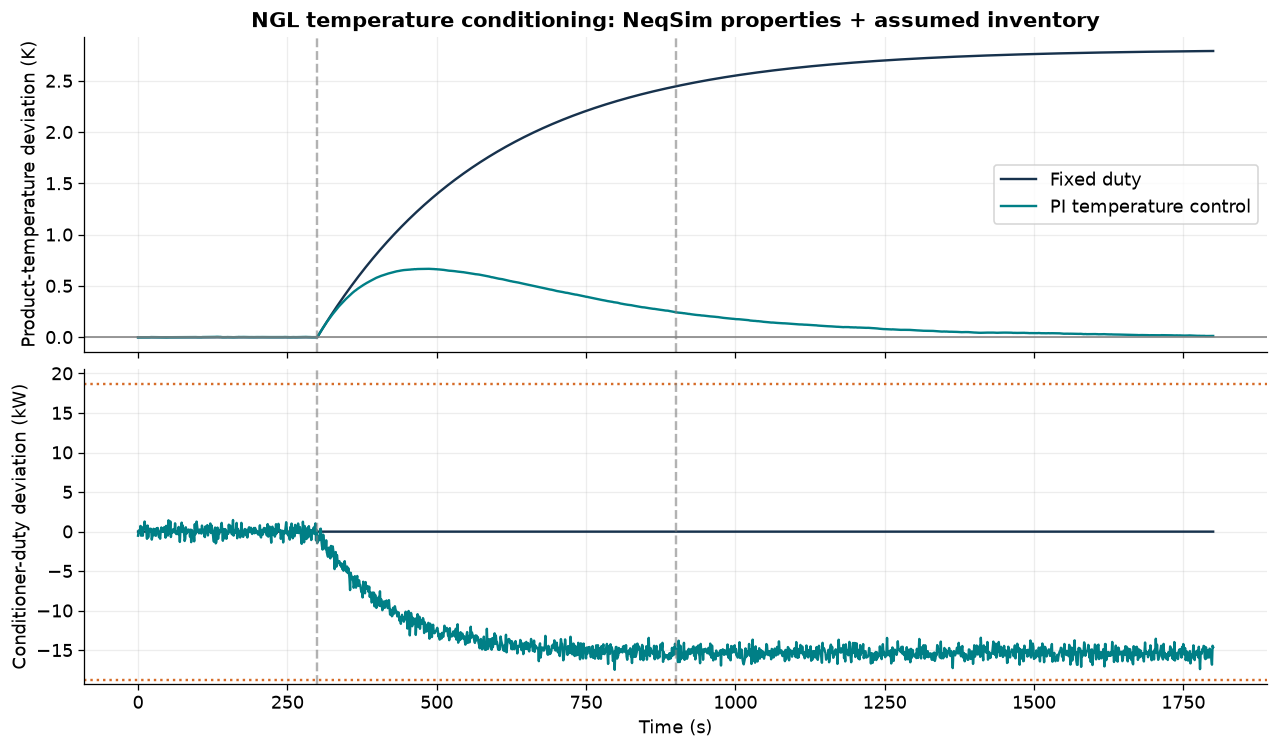

In [16]:
TAU_S = thermal_tau_s
DELAY_S = 8.0
LAMBDA_S = 120.0
K_C = TAU_S / (KQ * (LAMBDA_S + DELAY_S))
I_TIME_S = TAU_S
DUTY_LIMIT_KW = 0.50 * thermal_duty_kw


def control_simulation(closed_loop, dt=1.0, tau=TAU_S, gain_scale=1.0, noise=0.05):
    clock = np.arange(0.0, 1800.0 + dt / 2, dt)
    rng = np.random.default_rng(3697)
    temperature = np.zeros(len(clock))
    command = np.zeros(len(clock))
    applied = np.zeros(len(clock))
    measured = np.zeros(len(clock))
    feed_step = np.where(clock >= 300.0, 3.0, 0.0)
    pressure_step = np.where(clock >= 900.0, 0.5, 0.0)
    delay_steps = int(round(DELAY_S / dt))
    assert abs(delay_steps * dt - DELAY_S) < 1e-9
    integral = 0.0
    decay = np.exp(-dt / tau)
    for index in range(len(clock)):
        measured[index] = temperature[index] + rng.normal(0.0, noise)
        error = -measured[index]
        if closed_loop:
            unconstrained = K_C * error + integral
            command[index] = np.clip(unconstrained, -DUTY_LIMIT_KW, DUTY_LIMIT_KW)
            can_integrate = (
                abs(unconstrained) <= DUTY_LIMIT_KW
                or (unconstrained - command[index]) * K_C * error < 0
            )
            if can_integrate:
                integral += K_C * error * dt / I_TIME_S
        applied[index] = command[index - delay_steps] if index >= delay_steps else 0.0
        if index + 1 < len(clock):
            target = gain_scale * (
                KQ * applied[index] + KF * feed_step[index] + KP * pressure_step[index]
            )
            temperature[index + 1] = decay * temperature[index] + (1 - decay) * target
    return pd.DataFrame({
        "Time (s)": clock,
        "Product deviation (K)": temperature,
        "Measured deviation (K)": measured,
        "Duty deviation (kW)": command,
        "Applied duty deviation (kW)": applied,
        "Feed disturbance (K)": feed_step,
        "Pressure disturbance (bar)": pressure_step,
    })


open_loop = control_simulation(False)
closed_loop = control_simulation(True)
figure, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)
for frame, label, color in [
    (open_loop, "Fixed duty", NAVY), (closed_loop, "PI temperature control", TEAL),
]:
    axes[0].plot(frame["Time (s)"], frame["Product deviation (K)"], label=label, color=color)
    axes[1].plot(frame["Time (s)"], frame["Duty deviation (kW)"], label=label, color=color)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set(
    ylabel="Product-temperature deviation (K)",
    title="NGL temperature conditioning: NeqSim properties + assumed inventory",
)
axes[0].legend()
axes[1].axhline(DUTY_LIMIT_KW, color=ORANGE, linestyle=":")
axes[1].axhline(-DUTY_LIMIT_KW, color=ORANGE, linestyle=":")
axes[1].set(xlabel="Time (s)", ylabel="Conditioner-duty deviation (kW)")
for axis in axes:
    axis.axvline(300, color="gray", linestyle="--", alpha=0.6)
    axis.axvline(900, color="gray", linestyle="--", alpha=0.6)
plt.show()

In [17]:
def response_metrics(frame):
    clock = frame["Time (s)"].to_numpy()
    deviation = frame["Product deviation (K)"].to_numpy()
    command = frame["Duty deviation (kW)"].to_numpy()
    return {
        "IAE (K·s)": float(np.trapezoid(np.abs(deviation), clock)),
        "Peak deviation (K)": float(np.max(np.abs(deviation))),
        "Final mean deviation (K)": float(np.mean(deviation[clock >= 1650])),
        "Peak duty movement (kW)": float(np.max(np.abs(command))),
        "At duty limit (%)": 100 * float(np.mean(np.abs(command) >= DUTY_LIMIT_KW - 1e-8)),
    }


control_metrics = pd.DataFrame(
    [response_metrics(open_loop), response_metrics(closed_loop)],
    index=["Fixed duty", "PI temperature control"],
)
display(control_metrics.round(4))
iae_reduction = 100 * (
    1 - control_metrics.loc["PI temperature control", "IAE (K·s)"]
    / control_metrics.loc["Fixed duty", "IAE (K·s)"]
)
display(Markdown(
    f"PI control reduces integrated absolute temperature error by **{iae_reduction:.1f}%** "
    "in this assumed dynamic model. Integral action adjusts heat to offset sustained "
    "disturbances, while the delay and lag govern the response speed. This result supports "
    "a controller-screening experiment; it does not establish plant stability, hardware "
    "performance, or an NGL-recovery gain. Record an actual duty-step response before tuning "
    "a plant controller, and include composition and pressure measurements."
))

,IAE (K·s),Peak deviation (K),Final mean deviation (K),Peak duty movement (kW),At duty limit (%)
Fixed duty,3398.0828,2.7920,2.7870,0.0000,0.0
PI temperature control,356.2828,0.6674,0.0186,17.4767,0.0


PI control reduces integrated absolute temperature error by **89.5%** in this assumed dynamic model. Integral action adjusts heat to offset sustained disturbances, while the delay and lag govern the response speed. This result supports a controller-screening experiment; it does not establish plant stability, hardware performance, or an NGL-recovery gain. Record an actual duty-step response before tuning a plant controller, and include composition and pressure measurements.

## 9. Numerical and assumption sensitivity

Check the implementation against an analytical first-order response, halve the
time step without noise, and repeat control screening across assumed gain and
lag multipliers. This tests the small control model; it is not an independent
validation of the NeqSim EOS or a rigorous dynamic-column benchmark.

For fixed duty, the two ideal disturbance steps have the exact response

$$\Delta T(t)=\sum_k A_k\left[1-\exp\left(-\frac{t-t_k}{\tau}\right)\right]\,\mathbb{1}_{t\geq t_k}$$

$A_k$ is the steady disturbance response in K, $t_k$ is its start time in s,
and the indicator is one after the step and zero before it. Duty delay is irrelevant
for this fixed-duty analytical case because duty deviation remains zero.

Analytical fixed-duty maximum error: 4.619e-14 K
1.0 s versus 0.5 s controlled trajectory difference: 0.0009 K


,Gain multiplier,Lag (s),IAE (K·s),Peak deviation (K),Final mean deviation (K),Peak duty movement (kW),At duty limit (%)
0,0.7,194.3074,350.6927,0.6125,0.0287,15.2971,0.0
1,0.7,290.0111,354.4172,0.5747,0.0224,15.3808,0.0
2,0.7,435.0166,362.2349,0.5333,0.0111,15.9661,0.0
3,1.0,194.3074,353.7364,0.7078,0.0209,15.3447,0.0
4,1.0,290.0111,355.9696,0.6652,0.0158,15.3835,0.0
5,1.0,435.0166,360.2426,0.6185,0.0045,16.0065,0.0
6,1.3,194.3074,354.9636,0.7776,0.0173,15.3604,0.0
7,1.3,290.0111,356.4824,0.7319,0.0135,15.3836,0.0
8,1.3,435.0166,359.0945,0.6821,0.0053,15.9947,0.0


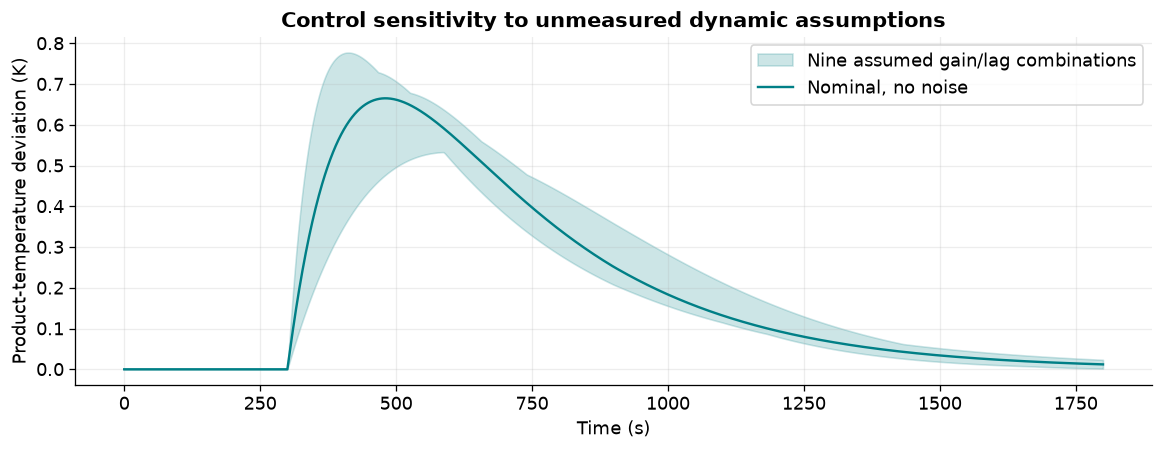

In [18]:
clock = open_loop["Time (s)"].to_numpy()
analytical = np.zeros_like(clock)
for start, amplitude in [(300.0, 3.0 * KF), (900.0, 0.5 * KP)]:
    elapsed = np.maximum(clock - start, 0.0)
    analytical += amplitude * (1.0 - np.exp(-elapsed / TAU_S))
analytical_error = float(np.max(np.abs(open_loop["Product deviation (K)"] - analytical)))
coarse = control_simulation(True, dt=1.0, noise=0.0)
fine = control_simulation(True, dt=0.5, noise=0.0)
time_step_error = float(np.max(np.abs(
    coarse["Product deviation (K)"].to_numpy()
    - fine["Product deviation (K)"].to_numpy()[::2]
)))
robustness_rows = []
robustness_frames = []
for gain_scale in [0.7, 1.0, 1.3]:
    for tau in [TAU_S * 0.67, TAU_S, TAU_S * 1.5]:
        frame = control_simulation(True, tau=tau, gain_scale=gain_scale, noise=0.0)
        metrics = response_metrics(frame)
        robustness_frames.append(frame["Product deviation (K)"].to_numpy())
        robustness_rows.append({"Gain multiplier": gain_scale, "Lag (s)": tau, **metrics})
robustness_table = pd.DataFrame(robustness_rows)
display(robustness_table.round(4))
print(f"Analytical fixed-duty maximum error: {analytical_error:.3e} K")
print(f"1.0 s versus 0.5 s controlled trajectory difference: {time_step_error:.4f} K")
figure, axis = plt.subplots(figsize=(10, 3.8))
envelope = np.array(robustness_frames)
axis.fill_between(clock, envelope.min(axis=0), envelope.max(axis=0), alpha=0.2,
                  color=TEAL, label="Nine assumed gain/lag combinations")
axis.plot(clock, coarse["Product deviation (K)"], color=TEAL, label="Nominal, no noise")
axis.set(xlabel="Time (s)", ylabel="Product-temperature deviation (K)",
         title="Control sensitivity to unmeasured dynamic assumptions")
axis.legend()
plt.show()

The envelope makes the uncertainty in the assumed dynamics visible. These nine
scenarios vary every steady gain together and the lag; they do not span all
possible plant behavior. They exclude sensor failures, changing delay, inverse
response, flooding, actuator nonlinearity, and composition dynamics. Use the
numerical error above to judge integration adequacy, then replace assumed dynamics
with identified plant data before drawing operating conclusions.

## 10. Retained validation evidence and reusable results

Acceptance uses explicit material and energy tolerances and independently checks
all operating points used for the search or local gains. The thermodynamic evidence
level is conservation plus EOS equilibrium consistency; **no experimental accuracy
claim** is made. The analytical response adds independent verification of the
assumed control model's numerical integration.

In [19]:
all_cases = [baseline, *scan_cases, bottom_minus, bottom_plus, feed_minus, feed_plus,
             pressure_minus, pressure_plus, fine_bottom_minus, fine_bottom_plus,
             fine_feed_minus, fine_feed_plus, fine_pressure_minus, fine_pressure_plus]
validation_checks = {
    "Feed compositions sum to one": abs(MOLE_FRACTIONS.sum() - 1.0) < 1e-12,
    "Cold separator component closure < 1e-6 mol/s": (
        cold_table["Component error (mol/s)"].max() < 1e-6
    ),
    "Cold separator energy closure < 0.1 W": cold_table["Energy error (W)"].abs().max() < 0.1,
    "Every column point passes all independent acceptance checks": all(
        all(case["checks"].values()) for case in all_cases
    ),
    "Selected point satisfies both constraints": bool(selected_row["Feasible"]),
    "Selected point minimizes duty on feasible grid": np.isclose(
        selected["reboiler_kw"], scan_table.loc[feasible_indices, "Reboiler (kW)"].min()
    ),
    "Thermal cp half-step change < 1%": thermal_gain_step_error < 0.01,
    "Native Heater sensible duty agreement < 1e-5 kW": native_heater_error_kw < 1e-5,
    "Qualified thermal duty gain is positive and finite": np.isfinite(KQ) and KQ > 1e-5,
    "Analytical open-loop agreement < 1e-9 K": analytical_error < 1e-9,
    "Half-step trajectory agreement < 0.05 K": time_step_error < 0.05,
    "PI improves temperature IAE in assumed model": iae_reduction > 0,
    "All actuator commands respect configured bounds": (
        closed_loop["Duty deviation (kW)"].abs().max() <= DUTY_LIMIT_KW + 1e-10
    ),
    "All sensitivity trajectories are finite": np.isfinite(envelope).all(),
}
validation_table = pd.DataFrame({
    "Check": list(validation_checks), "Passed": list(validation_checks.values()),
})
display(validation_table)
failed_checks = [name for name, passed in validation_checks.items() if not passed]
assert not failed_checks, failed_checks

balance_summary = pd.DataFrame({
    "Audit": ["Stage component", "External component", "External mass",
              "Interior energy", "External energy"],
    "Maximum across cases": [
        max(case["component_error"] for case in all_cases),
        max(case["external_component_error"] for case in all_cases),
        max(case["mass_relative_error"] for case in all_cases),
        max(case["interior_energy_relative_error"] for case in all_cases),
        max(case["external_energy_relative_error"] for case in all_cases),
    ],
    "Units": ["mol/s", "mol/s", "relative", "relative", "relative"],
})
display(balance_summary)

results_directory = Path("gas_distillation_results")
results_directory.mkdir(exist_ok=True)
summary = {
    "provenance": provenance,
    "selected_case": {key: float(value) for key, value in case_row(selected).items()},
    "trial_column_control_stage": control_stage,
    "column_gains_qualified": column_gains_qualified,
    "control_model": "NGL product conditioning; frozen composition; assumed inventory and UA",
    "gains": {"duty_K_per_kW": KQ, "feed_K_per_K": KF, "pressure_K_per_bar": KP},
    "assumed_dynamics": {"tau_s": TAU_S, "delay_s": DELAY_S, "PI_Kc_kW_per_K": K_C},
    "checks_passed": len(validation_checks),
    "column_calculations": len(all_cases),
    "rejected_grid_points": scan_rejections,
    "column_gain_step_relative_change": gain_relative_change.tolist(),
    "thermal_cp_step_relative_error": thermal_gain_step_error,
    "thermal_duty_kw": thermal_duty_kw,
    "control_IAE_reduction_percent": float(iae_reduction),
    "analytical_error_K": analytical_error,
    "time_step_error_K": time_step_error,
    "limitations": ["Synthetic inputs", "Audited duties required: NeqSim #3698",
                    "Assumed reduced dynamics", "No experimental validation"],
}
(results_directory / "summary.json").write_text(json.dumps(summary, indent=2))
for filename, frame in {
    "cold_separator.csv": cold_table,
    "column_operating_grid.csv": scan_table,
    "tray_sensitivities.csv": sensitivity_table,
    "control_metrics.csv": control_metrics,
    "PI_trajectory.csv": closed_loop,
    "validation.csv": validation_table,
}.items():
    frame.to_csv(results_directory / filename, index=False)
print(
    f"All {len(validation_checks)} summary checks passed "
    f"across {len(all_cases)} column calculations."
)
print("Reusable exports:", ", ".join(sorted(path.name for path in results_directory.iterdir())))
print("Reusable column objects: selected['process'], selected['column'], selected['feed']")
print("Reusable thermal objects: thermal_process, thermal_heater, native_thermal_feed")

All 14 summary checks passed across 20 column calculations.
Reusable exports: PI_trajectory.csv, cold_separator.csv, column_operating_grid.csv, control_metrics.csv, summary.json, tray_sensitivities.csv, validation.csv
Reusable column objects: selected['process'], selected['column'], selected['feed']
Reusable thermal objects: thermal_process, thermal_heater, native_thermal_feed


,Check,Passed
0,Feed compositions sum to one,True
1,Cold separator component closure < 1e-6 mol/s,True
2,Cold separator energy closure < 0.1 W,True
3,Every column point passes all independent acceptance checks,True
4,Selected point satisfies both constraints,True
5,Selected point minimizes duty on feasible grid,True
6,Thermal cp half-step change < 1%,True
7,Native Heater sensible duty agreement < 1e-5 kW,True
8,Qualified thermal duty gain is positive and finite,True
9,Analytical open-loop agreement < 1e-9 K,True


,Audit,Maximum across cases,Units
0,Stage component,3.07445e-08,mol/s
1,External component,2.06505e-08,mol/s
2,External mass,9.36940e-11,relative
3,Interior energy,2.73948e-09,relative
4,External energy,6.75390e-09,relative


## 11. What this enables next

The notebook demonstrates a useful research chain: temperature affects phase
split; staged fractionation changes product recovery and quality; energy balances
make duty-based decisions accountable; finite differences reveal whether column
gains are usable; and a separate NGL conditioning model uses NeqSim properties
to support a qualified thermal-control screening exercise. The worked column is an NGL deethanizer,
while the paper concerns a cryogenic reboiled absorber/demethanizer.

To validate the actual paper or a plant, obtain the full composition and flow basis,
stage count convention and feed stages, pressure profile, heat duties, tray/packing
efficiency, liquid/vapor inventories, pressure and level loops, actuator limits,
sensor response, sample period, controller settings, and numerical disturbance
records. Define measurement uncertainties and compare both steady and dynamic
outputs on that same basis.

Suggested exercises:

1. Refine the listed candidate grid with accepted intermediate points and quantify how the selected duty changes.
2. Change the illustrative ethane specification. Report an infeasible search honestly.
3. Vary condenser temperature and observe the heat/recovery tradeoff.
4. Recalculate gains at another operating point; compare the selected internal tray.
5. Add a pressure-compensated temperature signal and test it against an independently
   identified pressure response.
6. Resolve #3698, then require native duties and accepted-stream audit duties to agree
   before removing the workaround or integrating utility energy ports.

**Tracked limitations:** [terminal duties and tray inlet publication #3698](https://github.com/equinor/neqsim/issues/3698);
[distillation solver roadmap #2936](https://github.com/equinor/neqsim/issues/2936).
The rejected cryogenic cold-start trial is a bounded solver/initialization limitation,
not evidence that this process is physically infeasible.

## References and related examples

- Muhammad, M. M., Isah, I. R., Yusuf, F. G., and Nura, A. S. (2026).
  *Efficient Temperature Control for Optimizing Gas Distillation Columns in Nigeria's
  Gas Processing Industry*. SPE-234910-MS. [Publisher / DOI](https://doi.org/10.2118/234910-MS).
  Abstract only; no numerical replication is claimed.
- [Research-scan opportunity #3697](https://github.com/equinor/neqsim/issues/3697).
- [NeqSim distillation documentation at the tested source](https://github.com/equinor/neqsim/blob/1e7fda16e3872f74d918367a708737fbbad93927/docs/process/equipment/distillation.md).
- [DistillationColumn implementation at the tested source](https://github.com/equinor/neqsim/blob/1e7fda16e3872f74d918367a708737fbbad93927/src/main/java/neqsim/process/equipment/distillation/DistillationColumn.java).
- [Existing distillation tutorial](distillationoilgas.ipynb).
- [Process-control tutorial](process_control_with_neqsim_v2.ipynb).
- [NeqSim examples catalog](../examples_of_NeqSim_in_Colab.ipynb).